# Notebook #5: Immune Subsetting & Annotation

This analysis subsets the entire single cell object only for immune cells and annotates similarly to the previous notebook. Initial annotations were retrieved from CellTypist, and then manually validated using the top expressed genes and compared against canonical markers for each immune type.

Proliferating cells were removed for downstream senescence evaluation, and neutrophils were merged with classical monocytes due to low cell number(17).

In [1]:
!pip install -q \
seaborn \
matplotlib \
scanpy \
numpy==2.0.2 \
igraph \
harmonypy \
anndata \
celltypist

In [2]:
# -- Load libraries
from pathlib import Path

import scanpy as sc
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import harmonypy
import celltypist as ct

import anndata as ad
ad.settings.allow_write_nullable_strings = True


/Users/elenaeyre/Desktop/Science/Courses/Udacity/AI_4_Healthcare/Course_3/Project_Lesson_6/nd320-c1-emr-data-starter/.venv/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    BASE_DIR = Path("/content/drive/MyDrive/endometriosis-spatial-immune-atlas-main")
except ImportError:
    BASE_DIR = Path("/Users/elenaeyre/Desktop/Science/spatial_tx/endometriosis-spatial-immune-atlas-main")

In [5]:
# -- Paths
project_dir = BASE_DIR

dataset = "GSE179640"

interim_data_dir = (
    project_dir
    / "data"
    / "interim"
    / dataset
)


annotation_results_dir = (
    project_dir
    / "results"
    / dataset
    / "annotation"
)

annotation_figures_dir = (
    project_dir
    / "figures"
    / dataset
    / "annotation"
)

annotation_results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

annotation_figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

input_file = (
    interim_data_dir
    / "clustered_validated.h5ad"
)

In [6]:
# -- Parameters
log_fold_threshold = 1.5
p_val_threshold = 0.05

In [7]:
# -- Color Palettes
patient_colors_list = [
    sns.husl_palette(n_colors=1, h=h, s=0.9, l=0.65).as_hex()[0]
    for h in np.linspace(0.01, 0.70, 14)
]

# map to patient IDs
patient_ids = ["C01", "C02", "C03",
               "E01", "E02", "E03", "E04", "E05",
               "E06", "E07", "E08", "E09", "E10", "E11"]

patient_palette = dict(zip(patient_ids, patient_colors_list))

tissue_palette = {
    "Ctrl": "#7FA25C",
    "EuE":  "#028090",
    "EcP":  "#456990",
    "EcO":  "#CE7DA5"
}

immune_palette = {
    # -- Macrophages / Monocytes (warm tones)
    "Classical Monocytes": "#E07B54",
    "Non-Classical Monocytes":"#F2A65A",
    "Tissue Resident Macrophages": "#C14F3A",

    # -- Dendritic cells (purples)
    "cDC1": "#7B4FA6",
    "cDC2": "#A87DC2",
    "pDC": "#C9A8E0",

    # -- NK cells (greens)
    "CD16+ NK cells": "#2D8C6E",
    "CD16- NK cells": "#6DBF9E",

    # -- T cells (blues)

    "CD4 T cells": "#0B4A7E",
    "CD8 T cells": "#2E6FA3",
    "Tregs": "#5B9EC9",
    "γδ T cells": "#A8CBE0",


    # -- B cells (yellow)
    "B cells": "#E8C84A"
}

In [8]:
# -- Import clustered object
combined = sc.read_h5ad(input_file)
print(combined)

AnnData object with n_obs × n_vars = 94891 × 30907
    obs: 'sample_id', 'patient_id', 'tissue_type', 'condition', 'lesion_site', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribos', 'pct_counts_ribos', 'total_counts_hemos', 'pct_counts_hemos', 'n_genes', 'n_counts', 'outlier_mt', 'doublet_score', 'predicted_doublet', 'leiden_res_0.01', 'leiden_res_0.02', 'leiden_res_0.05', 'cluster_label'
    var: 'hemos', 'ribos', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cluster_label_colors', 'hvg', 'leiden_res_0.01', 'leiden_res_0.01_colors', 'leiden_res_0.02', 'leiden_res_0.02_colors', 'leiden_res_0.05', 'leiden_res_0.05_colors', 'log1p', 'neighbors', 'patient_id_colors', 'pca', 'predicted_doublet_colors', 'rank_genes_groups', 'scrublet', 'tissue_type_colors', 'um

In [9]:
# -- Subset immune cells (lymp & myeloid)
immune_obj = combined[combined.obs['cluster_label'].isin(['Lymphoid', 'Myeloid'])].copy()

print(
    f"Immune subset: "
    f"{immune_obj.n_obs} cells × "
    f"{immune_obj.n_vars} genes"
)

Immune subset: 29036 cells × 30907 genes


In [10]:
# -- Select HVGs
sc.pp.highly_variable_genes(
    immune_obj,
    n_top_genes=2000,
    batch_key="sample_id",
)

sc.pl.highly_variable_genes(
    immune_obj,
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_highly_variable_genes.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

print(
    f"Highly variable genes: "
    f"{immune_obj.var['highly_variable'].sum()}"
)

Highly variable genes: 2000


In [11]:
# -- Dimensionality reduction
sc.tl.pca(
    immune_obj,
    mask_var="highly_variable",
    n_comps=50,
    random_state=3,
)

In [12]:
# -- PCA variance
sc.pl.pca_variance_ratio(
    immune_obj,
    n_pcs=50,
    log=True,
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_pca_variance.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

In [13]:
# -- PCA diagnostics
sc.pl.pca(
    immune_obj,
    color=[
        "patient_id",
        "patient_id",
        "pct_counts_mt",
        "pct_counts_mt",
    ],
    dimensions=[
        (0, 1),
        (2, 3),
        (0, 1),
        (2, 3),
    ],
    ncols=2,
    size=2,
    title=[
        "Patient ID: PC1 vs PC2",
        "Patient ID: PC3 vs PC4",
        "Mitochondrial Percentage: PC1 vs PC2",
        "Mitochondrial Percentage: PC3 vs PC4",
    ],
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_pca_diagnostics.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

In [14]:
# -- Batch correction
harmony_output = harmonypy.run_harmony(
    immune_obj.obsm["X_pca"],
    immune_obj.obs,
    "sample_id",
)

immune_obj.obsm["X_pca_harmony"] = (
    harmony_output.Z_corr
)

2026-10-05 19:21:34,978 - harmonypy - INFO - Running Harmony
Running Harmony
2026-10-05 19:21:34,979 - harmonypy - INFO -   Parameters:
  Parameters:
2026-10-05 19:21:34,979 - harmonypy - INFO -     max_iter_harmony: 10
    max_iter_harmony: 10
2026-10-05 19:21:34,979 - harmonypy - INFO -     max_iter_kmeans: 4
    max_iter_kmeans: 4
2026-10-05 19:21:34,980 - harmonypy - INFO -     epsilon_cluster: 0.001
    epsilon_cluster: 0.001
2026-10-05 19:21:34,980 - harmonypy - INFO -     epsilon_harmony: 0.01
    epsilon_harmony: 0.01
2026-10-05 19:21:34,981 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-10-05 19:21:34,981 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-10-05 19:21:34,981 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
    lamb: dynamic (alpha=0.2)
2026-10-05 19:21:34,982 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
    theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 

In [15]:
# -- Nearest neighbors
sc.pp.neighbors(
    immune_obj,
    use_rep="X_pca_harmony",
    n_neighbors=15,
    random_state=3,
)

/Users/elenaeyre/Desktop/Science/Courses/Udacity/AI_4_Healthcare/Course_3/Project_Lesson_6/nd320-c1-emr-data-starter/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# -- UMAP
sc.tl.umap(
    immune_obj,
    random_state=3)

In [17]:
# -- UMAP by patient
sc.pl.umap(
    immune_obj,
    color="patient_id",
    palette=patient_palette,
    size=4,
    title="Immune Cells by Patient",
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_umap_patient.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()


# -- UMAP by tissue
sc.pl.umap(
    immune_obj,
    color="tissue_type",
    palette=tissue_palette,
    size=4,
    title="Immune Cells by Tissue",
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_umap_tissue.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

In [18]:
# -- Immune clustering
resolutions = [
    0.2,
    0.5,
    1.0,
]

for resolution in resolutions:
    key = f"leiden_res_{resolution:.2f}"

    sc.tl.leiden(
        immune_obj,
        key_added=key,
        resolution=resolution,
        flavor="igraph",
        n_iterations=2,
        random_state=0,
    )

    print(
        f"{key}: "
        f"{immune_obj.obs[key].nunique()} clusters"
    )

leiden_res_0.20: 12 clusters
leiden_res_0.50: 19 clusters
leiden_res_1.00: 28 clusters


In [19]:
# -- Compare clustering resolutions
sc.pl.umap(
    immune_obj,
    color=[
        "leiden_res_0.20",
        "leiden_res_0.50",
        "leiden_res_1.00",
    ],
    legend_loc="on data",
    title=[
        "Leiden Resolution 0.20",
        "Leiden Resolution 0.50",
        "Leiden Resolution 1.00",
    ],
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_leiden_resolutions.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

In [20]:

# -- Obtain cluster genes
sc.tl.rank_genes_groups(
    immune_obj,
    groupby="leiden_res_0.50",
    method="wilcoxon",
    use_raw=False,
)

In [21]:
# -- Markers
markers = sc.get.rank_genes_groups_df(
    immune_obj,
    group=None
)

markers = markers[
    (markers["logfoldchanges"] > log_fold_threshold) &
    (markers["pvals_adj"] < p_val_threshold)
    ].copy()

markers = markers.sort_values(
    ["group",
     "logfoldchanges",
    ],
    ascending=[
        True,
        False,
    ],
)

# save markers
markers.to_csv(
    annotation_results_dir
    / "05_immune_cluster_markers.csv",
    index=False,
)


top_markers = (
    markers
    .groupby(
        "group",
        observed=True,
    )
    .head(50)
)

for cluster in top_markers["group"].unique():
    print(f"\nCluster {cluster}")

    print(
        top_markers.loc[top_markers["group"] == cluster,
        "names"
        ].tolist()
    )


Cluster 0
['GPR20', 'PPP1R17', 'AC106712.1', 'LYPD2', 'CDKN1C', 'KNDC1', 'NEURL1', 'HES4', 'AC100803.3', 'CASP5', 'TCF7L2', 'AC064805.1', 'C10orf105', 'FCGR3A', 'SMIM25', 'TMEM63C', 'LST1', 'PTGDR2', 'ICAM4', 'HCAR3', 'AL158212.2', 'LINC02185', 'ADGRE1', 'TNFRSF8', 'GPBAR1', 'LINC02432', 'TMTC1', 'AIF1', 'LKAAEAR1', 'CEACAM3', 'SFTPD', 'FCN1', 'CDH23', 'SERPINA1', 'MS4A7', 'LILRA1', 'TRNP1', 'LILRB2', 'LILRA5', 'ZNF703', 'LINC02345', 'APOBEC3A', 'CFD', 'PTP4A3', 'SEZ6L', 'AATBC', 'SIGLEC10', 'PLAGL2', 'AC026369.3', 'LYNX1']

Cluster 1
['NOG', 'MAL', 'AC005842.1', 'CD40LG', 'IL7R', 'AC139720.1', 'LTK', 'ADTRP', 'FAM153A', 'B3GALT2', 'CCR7', 'IL2', 'RAB6B', 'LRRN3', 'TSPAN18', 'TSHZ2', 'ELOVL4', 'AC009041.1', 'TRABD2A', 'VSIG1', 'ANKRD55', 'FBLN7', 'MDS2', 'SLC4A10', 'AP003716.1', 'KIF5C', 'TTC39C-AS1', 'AC009041.2', 'LEF1', 'LINC00402', 'TNFRSF25', 'DPP4', 'AQP3', 'CMTM8', 'TCF7', 'CHRM3-AS2', 'AC013264.1', 'LTB', 'EPHX2', 'SCGB3A1', 'CD3D', 'LINC02273', 'TRAT1', 'CD3G', 'NELL2', 'ATG9

In [22]:
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

ct_model = ct.models.Model.load(
    model="Immune_All_Low.pkl"
)

# Celltypist annotation

predictions = ct.annotate(immune_obj,
                          model="Immune_All_Low.pkl", majority_voting=True, over_clustering = "leiden_res_0.50")


# convert back to obj
immune_obj = predictions.to_adata()


# save
celltypist_columns = [
    column
    for column in [
        "predicted_labels",
        "majority_voting",
        "conf_score",
    ]
    if column in immune_obj.obs.columns
]

immune_obj.obs[
    celltypist_columns
].to_csv(
    annotation_results_dir
    / "05_celltypist_predictions.csv"
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /Users/elenaeyre/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl
⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 29036 cells and 30907 genes
🔗 Matching reference genes in the model
🧬 6080 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


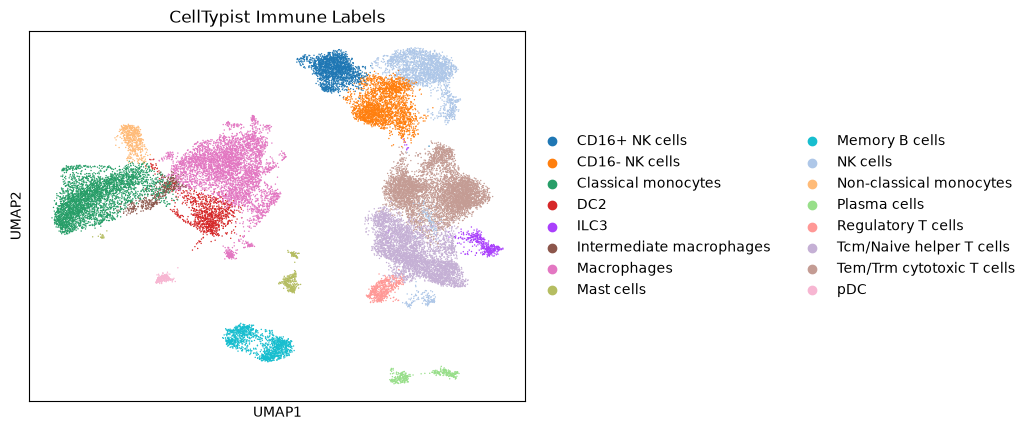

In [23]:
# -- Plot CellTypist labels
sc.pl.umap(
    immune_obj,
    color="majority_voting",
    ncols=1,
    title="CellTypist Immune Labels",
    show=False,
)

plt.savefig(
    annotation_figures_dir
    / "05_celltypist_annotation_immune.png",
    bbox_inches="tight",
    dpi=300,
)

In [24]:
immune_obj.obs["leiden_res_0.50"].value_counts().sort_index()

leiden_res_0.50
0      525
1     4274
2       85
3      255
4      558
5     5240
6     3785
7      973
8      528
9      426
10    3469
11    1836
12    2429
13     425
14    1886
15     470
16    1308
17     353
18     211
Name: count, dtype: int64

Cluster 9 expressed canonical markers including FCGR3B, CXCR2, and CSF3R. Due to its extremely low abundance, these cells were grouped with the classical monocyte lineage for downstream analyses to avoid unstable estimates.

In [25]:
# -- Immune markers
immune_labels = {
    "0": "Non-Classical Monocytes",
    "1": "CD4 T cells",
    "2": "CD16+ NK cells",
    "3": "γδ T cells",
    "4": "CD8 T cells",
    "5": "Proliferating",
    "6": "cDC2",
    "7": "Tissue Resident Macrophages",
    "8": "Classical Monocytes",
    "9": "Classical Monocytes",
    "10": "CD16- NK cells",
    "11": "Tregs",
    "12": "CD16- NK cells",
    "13": "B cells",
    "14": "cDC1",
    "15": "pDC",
}

immune_obj.obs["immune_cell_type"] = immune_obj.obs["leiden_res_0.50"].map(immune_labels)

# verify no NaN values
print(immune_obj.obs["immune_cell_type"].value_counts())
print(immune_obj.obs["immune_cell_type"].isna().sum())

immune_cell_type
CD16- NK cells                 5898
Proliferating                  5240
CD4 T cells                    4274
cDC2                           3785
cDC1                           1886
Tregs                          1836
Tissue Resident Macrophages     973
Classical Monocytes             954
CD8 T cells                     558
Non-Classical Monocytes         525
pDC                             470
B cells                         425
γδ T cells                      255
CD16+ NK cells                   85
Name: count, dtype: int64
1872


In [26]:
# -- Annotation validation
marker_genes = {
    "Classical Monocytes": [
        "S100A8",
        "S100A9",
        "CTSD",
    ],

    "Non-Classical Monocytes": [
        "FCGR3A",
        "LST1",
        "MS4A7",
    ],

    "Tissue Resident Macrophages": [
        "C1QA",
        "C1QB",
        "C1QC",
    ],

    "cDC1": [
        "CLEC9A",
        "BATF3",
        "CADM1",
    ],

    "cDC2": [
        "CD1C",
        "FCER1A",
        "CLEC10A",
    ],

    "pDC": [
        "GZMB",
        "GZMB",
        "JCHAIN",
    ],

    "CD16+ NK cells": [
        "FCGR3A",
        "KLRD1",
        "NKG7",
    ],

    "CD16- NK cells": [
        "GNLY",
        "XCL1",
        "XCL2",
    ],

    "CD4 T cells": [
        "CD4",
        "IL7R",
        "LTB",
    ],

    "CD8 T cells": [
        "CD8A",
        "CD8B",
        "CCL5",
    ],

    "Tregs": [
        "FOXP3",
        "IL2RA",
        "CTLA4",
    ],

    "γδ T cells": [
        "TRDC",
        "TRGC1",
        "TRGC2",
    ],

    "B cells": [
        "MS4A1",
        "CD79A",
        "CD37",
    ],
}

immune_cell_order = [
    "Classical Monocytes",
    "Non-Classical Monocytes",
    "Tissue Resident Macrophages",
    "cDC1",
    "cDC2",
    "pDC",
    "CD16+ NK cells",
    "CD16- NK cells",
    "CD4 T cells",
    "CD8 T cells",
    "Tregs",
    "γδ T cells",
    "B cells",
]

sc.pl.dotplot(
    immune_obj,
    marker_genes,
    groupby="immune_cell_type",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,
    figsize=(14, 7),
    show=False
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_marker_dotplot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.close()

... storing 'immune_cell_type' as categorical


In [27]:
# Adding shorter labels for plotting - lesson learned
cell_type_short = {
    "Classical Monocytes": "Mono-C",
    "Non-Classical Monocytes": "Mono-NC",
    "Tissue Resident Macrophages": "TRM",
    "cDC1": "cDC1",
    "cDC2": "cDC2",
    "pDC": "pDC",
    "CD16+ NK cells": "NK-CD16+",
    "CD16- NK cells": "NK-CD16-",
    "CD4 T cells": "CD4 T",
    "CD8 T cells": "CD8 T",
    "γδ T cells": "γδ T",
    "Tregs": "Treg",
    "B cells": "B",
    "Proliferating": "Cycling",
}

immune_obj.obs["cell_type_short"] = (
    immune_obj.obs["immune_cell_type"]
    .map(cell_type_short)
    .astype("category")
)

Also removing the "Proliferating cluster" because it's more of a cell state rather than a cell type. Especially since I am scoring senescence in the next analysis. I don't want it to interfere with accurate scoring by cell type.

In [28]:
# Remove proliferating cluster
n_proliferating = (
    immune_obj.obs["immune_cell_type"] == "Proliferating"
).sum()

print(f"Removing {n_proliferating} proliferating cells from downstream analyses.")

immune_obj = immune_obj[
    immune_obj.obs["immune_cell_type"] != "Proliferating"
].copy()

immune_obj.obs["cell_type_short"] = (
    immune_obj.obs["cell_type_short"]
    .cat.remove_unused_categories()
)

Removing 5240 proliferating cells from downstream analyses.


In [29]:
# -- Final Clustering
immune_obj.obs["immune_cell_type"] = (
    immune_obj.obs["immune_cell_type"]
    .astype("category")
    .cat.reorder_categories(list(immune_palette.keys()), ordered=True)
)

sc.pl.umap(immune_obj,
           color= "immune_cell_type",
           title = "Immune Subset Clustering", palette = immune_palette, show = False)

plt.savefig(
    annotation_figures_dir
    / "05_umap_immune_cell_types.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

In [30]:
# -- Cell-type counts within each tissue
cell_counts_by_tissue = pd.crosstab(
    immune_obj.obs["tissue_type"],
    immune_obj.obs["immune_cell_type"],
)

tissue_order = [
    "Ctrl",
    "EuE",
    "EcO",
    "EcP",
]

cell_counts_by_tissue = (
    cell_counts_by_tissue
    .reindex(tissue_order)
)

ax = cell_counts_by_tissue.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=immune_palette,
)

ax.set_ylabel("Number of Cells")
ax.set_xlabel("Tissue Type")

ax.legend(
    bbox_to_anchor=(1.05, 0.75),
    loc="upper left",
    borderaxespad=0,
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_cell_types_by_tissue.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

# save table
cell_counts_by_tissue.to_csv(
    annotation_results_dir
    / "05_cell_counts_by_tissue.csv",
    index=True,
)

In [31]:
# -- Tissue composition within each immune cell type
tissue_counts_by_cell_type = pd.crosstab(
    immune_obj.obs["immune_cell_type"],
    immune_obj.obs["tissue_type"],
)

tissue_counts_by_cell_type = (
    tissue_counts_by_cell_type
    .reindex(
        columns=list(tissue_palette),
        fill_value=0,
    )
)

ax = tissue_counts_by_cell_type.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=tissue_palette,
)

ax.set_ylabel("Number of Cells")
ax.set_xlabel("")

ax.legend(
    title="Tissue Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.savefig(
    annotation_figures_dir
    / "05_immune_tissues_by_cell_type.png",
    bbox_inches="tight",
    dpi=300,
)

plt.close()

# save table
tissue_counts_by_cell_type.to_csv(
    annotation_results_dir
    / "05_tissue_counts_by_cell_type.csv",
    index=True,
)

In [32]:
# -- Immune cell composition by tissue

immune_cell_order = [
    "Classical Monocytes",
    "Non-Classical Monocytes",
    "Tissue Resident Macrophages",
    "cDC1",
    "cDC2",
    "pDC",
    "CD16+ NK cells",
    "CD16- NK cells",
    "CD4 T cells",
    "CD8 T cells",
    "Tregs",
    "γδ T cells",
    "B cells",
]

tissue_order = [
    "Ctrl",
    "EuE",
    "EcO",
    "EcP",
]

# -- Count immune cells in each tissue
cell_counts = (
    immune_obj.obs
    .groupby(
        [
            "tissue_type",
            "immune_cell_type"
        ],
        observed=True
    )
    .size()
    .reset_index(name="cell_count")
)

# -- Calculate within-tissue proportions
cell_counts["percent"] = (
    cell_counts["cell_count"]
    / cell_counts.groupby(
        "tissue_type"
    )["cell_count"].transform("sum")
) * 100

# -- Pivot into a summary table
proportion_table = (
    cell_counts
    .pivot(
        index="immune_cell_type",
        columns="tissue_type",
        values="percent"
    )
    .fillna(0)
)

# -- Apply consistent ordering
proportion_table = proportion_table.reindex(
    [
        cell
        for cell in immune_cell_order
        if cell in proportion_table.index
    ]
)

proportion_table = proportion_table[
    [
        tissue
        for tissue in tissue_order
        if tissue in proportion_table.columns
    ]
]

proportion_table = proportion_table.round(1)

# -- Validation (each tissue should sum to ~100%)
print("Column totals:")
print(proportion_table.sum(axis=0))

display(proportion_table)

# -- Save outputs
cell_counts.to_csv(
    annotation_results_dir
    / "05_immune_cell_proportions_long.csv",
    index=False
)

proportion_table.to_csv(
    annotation_results_dir
    / "05_immune_cell_proportion_table.csv"
)

Column totals:
tissue_type
Ctrl     99.8
EuE     100.1
EcO      99.9
EcP     100.1
dtype: float64


tissue_type,Ctrl,EuE,EcO,EcP
immune_cell_type,,,,
Classical Monocytes,11.8,2.9,3.3,4.0
Non-Classical Monocytes,2.7,2.4,1.4,2.6
Tissue Resident Macrophages,5.4,2.8,2.7,6.2
cDC1,6.3,15.1,3.8,5.5
cDC2,13.3,13.2,35.0,15.7
pDC,1.6,2.6,0.9,2.3
CD16+ NK cells,0.3,0.4,0.4,0.4
CD16- NK cells,33.2,28.1,17.3,27.5
CD4 T cells,12.6,19.1,24.1,20.1


In [33]:
# -- Save subsetted object for senescence scoring
output_file = (
    interim_data_dir
    / "immune_annotated.h5ad"
)

# -- Save annotated immune object
immune_obj.write_h5ad(
    output_file
)

print(
    f"Saved immune object to:\n"
    f"{output_file}"
)

Saved immune object to:
/Users/elenaeyre/Desktop/Science/spatial_tx/endometriosis-spatial-immune-atlas-main/data/interim/GSE179640/immune_annotated.h5ad
